# Sequence Inspector (bulk corpus)

Sanity-checks every `.npz` file in `processed/sequences/` produced by `src/build_sequences_bulk.py`. Built for the post-ADR-0003 corpus (~420k files, gap-guarded segmentation, uniform schema).

Sections:

0. **Corpus index** — fast filename-only scan (no `np.load`) + zero-yield summary from the progress CSV
1. **Per-file deep checks** — 8 structural checks on a stratified sample (~5,000 files)
2. **Training-readiness checks**
   - 2a Gap-guard leak detection
   - 2b MAD-norm scale uniformity
   - 2c Per-sector yield + coverage
   - 2d TIC coverage vs `spoc_sector_map.csv`
   - 2e Outlier + duplicate audit
   - 2f v1 label coverage (rotation, transit, rotation-period regression)
3. **Distribution plots** — `df_checks` summary figures
4. **Detailed view** — random files plotted with real TBJD time axis
5. **Flux-outlier cleanup** — full-corpus scan + catalog cross-match (5a), then destructive delete + progress CSV patch (5b)

**NPZ schema (uniform):** `windows (N,1024,1) · times (N,1024) · tic_id · sector · seg_idx · run_idx · n_windows`. Flare label excluded throughout (ADR-0001). v1b spectroscopic intentionally out of scope.

In [1]:
import random

In [2]:

import re
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Paths ─────────────────────────────────────────────────────────────────────
SEQ_DIR      = Path("../../processed/sequences")
PROGRESS_CSV = Path("../../processed/build_sequences_bulk_progress.csv")
TARGET_CSV   = Path("../../processed/spoc_sector_map.csv")
LABELS_CSV   = Path("../../labels/variability_labels_star.csv")
OUTLIER_CSV  = Path("../../processed/flux_outliers_sample.csv")

# ── Schema constants (locked v1) ──────────────────────────────────────────────
T            = 1024              # window length (cadences)
STRIDE       = 1024              # stride used when building windows
SEQ_LEN      = 4                 # min windows per file to be training-usable

# ── Cadence ───────────────────────────────────────────────────────────────────
CADENCE_DAYS = 2 / 1440          # 2-min cadence in days (~0.001389)
CADENCE_TOL  = 2 * CADENCE_DAYS  # max allowed cross-window gap (2× cadence; matches Section 2a threshold)
TBJD_MIN     = 1000.0            # pathological lower bound (pre-TESS era)
TBJD_MAX     = 6000.0            # pathological upper bound

# ── Sampling / audit thresholds ───────────────────────────────────────────────
SAMPLE_PER_SECTOR  = 50          # stratified-sample cap per sector
SEED               = 11
FLUX_ABSMAX_THRESH = 20          # unusual after MAD-norm; cleanup via build_sequences_bulk_sanity.ipynb
MAD_RATIO_THRESH   = 3           # informational only — NOT a quality gate (see Section 2b)

## Section 0 — Corpus index + zero-yield summary

Cheap filename-only scan. No `np.load`. Parses `TIC<10d>_s<2d>_seg<2d>_run<2d>.npz` into a DataFrame and reports basic counts. Also reads `build_sequences_bulk_progress.csv` to print the (TIC, sector)-pair zero-yield rate under the gap-guard regime.

In [3]:
_FN_RE = re.compile(r"^TIC(\d+)_s(\d+)_seg(\d+)_run(\d+)\.npz$")


def build_corpus_index(seq_dir: Path) -> tuple[pd.DataFrame, list[str]]:
    """Parse every .npz filename in seq_dir into a DataFrame (no np.load).

    Returns (df[path, tic_id, sector, seg_idx, run_idx], list_of_unparsed_names).
    """
    rows: list[tuple] = []
    unparsed: list[str] = []
    for p in seq_dir.glob("*.npz"):
        m = _FN_RE.match(p.name)
        if m is None:
            unparsed.append(p.name)
            continue
        tic, sec, seg, run = (int(g) for g in m.groups())
        rows.append((str(p), tic, sec, seg, run))
    df = pd.DataFrame(
        rows, columns=["path", "tic_id", "sector", "seg_idx", "run_idx"]
    )
    return df, unparsed


def summarize_corpus(df: pd.DataFrame, unparsed: list[str]) -> None:
    """Print high-level corpus stats from the parsed index."""
    print(f"Files (parsed):       {len(df):>10,}")
    print(f"Files (unparsed):     {len(unparsed):>10,}")
    print(f"Distinct TICs:        {df['tic_id'].nunique():>10,}")
    print(f"Distinct sectors:     {df['sector'].nunique():>10,}")
    if df.empty:
        return
    files_per_sector = df.groupby("sector").size()
    max_sector = int(df["sector"].max())
    empty = sorted(set(range(1, max_sector + 1)) - set(files_per_sector.index))
    print(f"Sectors with 0 files (1..{max_sector}): {empty if empty else 'none'}")


def summarize_yield(progress_csv: Path) -> None:
    """One-liner zero-yield summary from the bulk progress CSV."""
    df = pd.read_csv(progress_csv, usecols=["status", "n_segments_saved"])
    n = len(df)
    zero = int((df["n_segments_saved"] == 0).sum())
    pos = n - zero
    print(f"Progress rows:       {n:>10,}")
    print(f"  yielded ≥1 window: {pos:>10,}  ({pos/n:.1%})")
    print(f"  yielded 0 windows: {zero:>10,}  ({zero/n:.1%})")
    print(f"  status counts:    {df['status'].value_counts().to_dict()}")


corpus_df, unparsed = build_corpus_index(SEQ_DIR)
summarize_corpus(corpus_df, unparsed)
print()
summarize_yield(PROGRESS_CSV)

Files (parsed):          420,063
Files (unparsed):              0
Distinct TICs:           120,320
Distinct sectors:             64
Sectors with 0 files (1..101): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 29, 30, 31, 35, 43, 44, 46, 69, 94, 95, 96]

Progress rows:          669,142
  yielded ≥1 window:    284,641  (42.5%)
  yielded 0 windows:    384,501  (57.5%)
  status counts:    {'done': 669142}


## Section 1 — Per-file deep checks (stratified sample)

Draws up to `SAMPLE_PER_SECTOR=50` files per sector (~5,000 files total) and runs all 8 legacy structural checks:

| Check | Pass condition |
|---|---|
| `windows` shape | `(N, 1024, 1)` with `N ≥ SEQ_LEN` |
| `windows` NaN count | must be 0 (Class-A guarantee) |
| `windows` flux range | `abs(max) ≤ FLUX_ABSMAX_THRESH` after MAD-norm |
| `times` shape | `(N, 1024)` parallel to windows |
| `times` TBJD range | `TBJD_MIN ≤ times ≤ TBJD_MAX` |
| `times` row monotonicity | each row strictly increasing |
| `times` cross-window gap | `times[i+1,0] - times[i,-1] ≤ CADENCE_TOL` |
| `n_windows` consistency | scalar equals `windows.shape[0]` |

In [4]:
def stratified_sample(
    df: pd.DataFrame, per_sector: int, seed: int
) -> list[Path]:
    """Sample up to `per_sector` files per sector (uniform random with `seed`)."""
    rng = np.random.default_rng(seed)
    paths: list[Path] = []
    for _, group in df.groupby("sector", sort=True):
        n = min(per_sector, len(group))
        idx = rng.choice(group.index.to_numpy(), size=n, replace=False)
        paths.extend(Path(p) for p in df.loc[idx, "path"])
    return paths


def check_file(p: Path) -> dict:
    """Run all 8 legacy structural checks on one NPZ file. Returns a row dict."""
    row: dict = {"file": p.name, "ok": True}
    flags: list[str] = []
    try:
        d = np.load(p, allow_pickle=True)
    except Exception as e:
        return {"file": p.name, "ok": False, "flags": f"load_error:{e}"}

    windows = d["windows"]               # (N, 1024, 1)
    times   = d["times"]                 # (N, 1024)
    n_win_scalar = int(d["n_windows"])
    N = windows.shape[0]
    row.update(
        n_windows=N,
        sector=int(d["sector"]),
        tic_id=int(d["tic_id"]),
    )

    if windows.ndim != 3 or windows.shape[1] != T or windows.shape[2] != 1:
        flags.append(f"windows_shape:{windows.shape}")
    if N < SEQ_LEN:
        flags.append(f"n_windows_lt{SEQ_LEN}:{N}")

    nan_count = int(np.isnan(windows).sum())
    row["windows_nan"] = nan_count
    if nan_count > 0:
        flags.append(f"windows_has_nan:{nan_count}")

    flux_absmax = float(np.nanmax(np.abs(windows)))
    row["flux_absmax"] = round(flux_absmax, 3)
    if flux_absmax > FLUX_ABSMAX_THRESH:
        flags.append(f"flux_absmax:{flux_absmax:.2f}")

    if times.ndim != 2 or times.shape != (N, T):
        flags.append(f"times_shape:{times.shape}")

    t_min, t_max = float(times.min()), float(times.max())
    row["tbjd_min"] = round(t_min, 3)
    row["tbjd_max"] = round(t_max, 3)
    if t_min < TBJD_MIN:
        flags.append(f"tbjd_too_low:{t_min:.2f}")
    if t_max > TBJD_MAX:
        flags.append(f"tbjd_too_high:{t_max:.2f}")

    non_mono_rows = int(np.sum(np.any(np.diff(times, axis=1) <= 0, axis=1)))
    row["times_non_mono_rows"] = non_mono_rows
    if non_mono_rows > 0:
        flags.append(f"times_not_monotone_rows:{non_mono_rows}")

    if N > 1:
        gaps = times[1:, 0] - times[:-1, -1]
        bad = int(np.sum(gaps > CADENCE_TOL))
        row["cross_window_bad_gaps"] = bad
        if bad > 0:
            flags.append(f"cross_window_gap:{bad}")
    else:
        row["cross_window_bad_gaps"] = 0
    row["cadence_median_days"] = round(float(np.median(np.diff(times[0]))), 6)

    if n_win_scalar != N:
        flags.append(f"n_windows_mismatch:scalar={n_win_scalar},actual={N}")

    if flags:
        row["ok"] = False
    row["flags"] = "; ".join(flags)
    return row


def run_checks(paths: list[Path], n_workers: int = 8) -> pd.DataFrame:
    """Apply check_file across paths in parallel (ThreadPool — IO-bound)."""
    with ThreadPoolExecutor(max_workers=n_workers) as pool:
        records = list(pool.map(check_file, paths))
    return pd.DataFrame(records)


sample_paths = stratified_sample(corpus_df, SAMPLE_PER_SECTOR, SEED)
print(f"Stratified sample size: {len(sample_paths)}  ({SAMPLE_PER_SECTOR} per sector)")

df_checks = run_checks(sample_paths)
n_ok  = int(df_checks["ok"].sum())
n_bad = int((~df_checks["ok"]).sum())
print(f"Passed: {n_ok} / {len(df_checks)}   Failed: {n_bad}")

if n_bad > 0:
    print("\nFailed files:")
    display(df_checks[~df_checks["ok"]][["file", "sector", "n_windows", "flags"]])

Stratified sample size: 3200  (50 per sector)
Passed: 3181 / 3200   Failed: 19

Failed files:


,file,sector,n_windows,flags
119,TIC0238227405_s32_seg06_run00.npz,32,4,flux_absmax:22.49
574,TIC0427328347_s42_seg03_run00.npz,42,4,flux_absmax:56.34
892,TIC0233496577_s51_seg144_run00.npz,51,4,flux_absmax:27.03
1291,TIC0459915346_s59_seg07_run00.npz,59,4,flux_absmax:60.82
1386,TIC0053292822_s61_seg00_run00.npz,61,4,flux_absmax:38.59
1451,TIC0260132330_s63_seg02_run00.npz,63,4,flux_absmax:44.63
1482,TIC0355152640_s63_seg00_run00.npz,63,4,flux_absmax:30.35
1496,TIC0106403786_s63_seg00_run00.npz,63,4,flux_absmax:27.92
1598,TIC0133701671_s65_seg00_run00.npz,65,4,flux_absmax:122.31
2039,TIC0356015357_s75_seg08_run00.npz,75,4,flux_absmax:199.87


## Section 2a — Gap-guard verification

Under the post-ADR-0003 segmentation, windows inside one segment are always adjacent (`stride==window_size==1024`) with no observing gap straddling them. Cross-window gap should be ~1 cadence (`~0.00139 d`). Any file where `times[i+1, 0] - times[i, -1] > 2 × CADENCE_DAYS` indicates the gap-guard didn't fully land — would break the GRU dynamics contract. Expected count: 0.

In [5]:
def check_gap_guard(
    paths: list[Path], threshold_mult: float = 2.0
) -> pd.DataFrame:
    """For each file, count adjacent-window gaps > `threshold_mult` × cadence.

    Cross-window gap = times[i+1, 0] - times[i, -1]. Since stride==window_size,
    adjacent windows inside one segment should be ~1 cadence apart. A gap
    larger than that means a downlink leaked through the gap-guard.
    """
    thresh = threshold_mult * CADENCE_DAYS
    out = []
    for p in paths:
        d = np.load(p, allow_pickle=True)
        times = d["times"]
        if times.shape[0] < 2:
            out.append({"file": p.name, "max_gap_days": 0.0, "leak_count": 0})
            continue
        gaps = times[1:, 0] - times[:-1, -1]
        out.append({
            "file":         p.name,
            "max_gap_days": float(gaps.max()),
            "leak_count":   int(np.sum(gaps > thresh)),
        })
    return pd.DataFrame(out)


df_gap = check_gap_guard(sample_paths)
leaks = df_gap[df_gap["leak_count"] > 0]
print(f"Files with cross-window gap > 2× cadence "
      f"({2*CADENCE_DAYS:.4f} d): {len(leaks)} / {len(df_gap)}")
if len(leaks):
    display(leaks.sort_values("max_gap_days", ascending=False).head(20))

Files with cross-window gap > 2× cadence (0.0028 d): 0 / 3200


## Section 2b — MAD-norm scale sanity

Per-file MAD (`1.4826 * median(|x - median(x)|)`) computed independently for each window. Since MAD-normalization is per-segment in `build_sequences_bulk.py` (not per-window), the windows from one segment share the same normalising constant — so their per-window MADs should be similar. Files with `max(MAD)/min(MAD) > MAD_RATIO_THRESH` (=3) contain extreme intra-segment variability (flare in one window vs quiet in another).

**This check is informational only.** High MAD ratio is valid astrophysical variability (rotating/flaring stars); these files are NOT filtered. `check_file()` does not use `MAD_RATIO_THRESH`.

Files with max/min MAD ratio > 3: 191 / 3200  (6.0%)


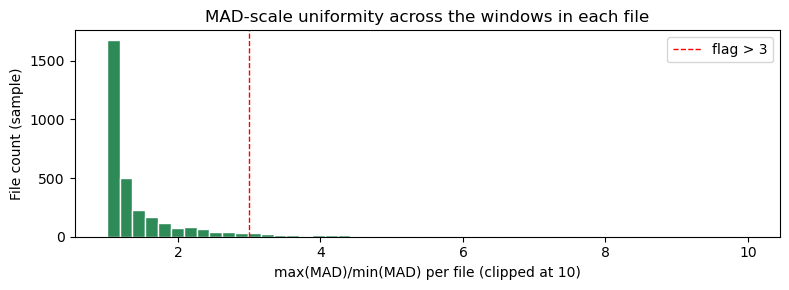

In [6]:
def _mad(x: np.ndarray) -> float:
    """Median absolute deviation, scaled to match the std of a Gaussian."""
    return float(1.4826 * np.median(np.abs(x - np.median(x)))) if x.size else 0.0


def check_mad_scale(paths: list[Path]) -> pd.DataFrame:
    """Per-file MAD-scale uniformity: ratio of max(MAD)/min(MAD) across windows."""
    out = []
    for p in paths:
        d = np.load(p, allow_pickle=True)
        w = d["windows"].squeeze(-1)               # (N, 1024)
        mads = np.array([_mad(row) for row in w])
        mads = np.where(mads <= 0, np.nan, mads)
        ratio = (
            float(np.nanmax(mads) / np.nanmin(mads))
            if np.any(np.isfinite(mads)) else np.nan
        )
        out.append({
            "file":    p.name,
            "min_mad": float(np.nanmin(mads)) if np.any(np.isfinite(mads)) else np.nan,
            "max_mad": float(np.nanmax(mads)) if np.any(np.isfinite(mads)) else np.nan,
            "ratio":   ratio,
        })
    return pd.DataFrame(out)


df_mad = check_mad_scale(sample_paths)
bad = df_mad[df_mad["ratio"] > MAD_RATIO_THRESH]
print(f"Files with max/min MAD ratio > {MAD_RATIO_THRESH}: "
      f"{len(bad)} / {len(df_mad)}  ({len(bad)/max(len(df_mad),1):.1%})")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(df_mad["ratio"].clip(upper=10), bins=50, color="seagreen", edgecolor="white")
ax.axvline(MAD_RATIO_THRESH, color="red", linestyle="--", linewidth=1,
           label=f"flag > {MAD_RATIO_THRESH}")
ax.set_xlabel("max(MAD)/min(MAD) per file (clipped at 10)")
ax.set_ylabel("File count (sample)")
ax.set_title("MAD-scale uniformity across the windows in each file")
ax.legend(); plt.tight_layout(); plt.show()

## Section 2c — Per-sector yield + coverage

Two-panel bar chart over the **full** corpus index (cheap — no `np.load`): files-per-sector and distinct-TIC-per-sector. Sectors with zero files indicate a curl-script download failure or full gap-guard fallout.

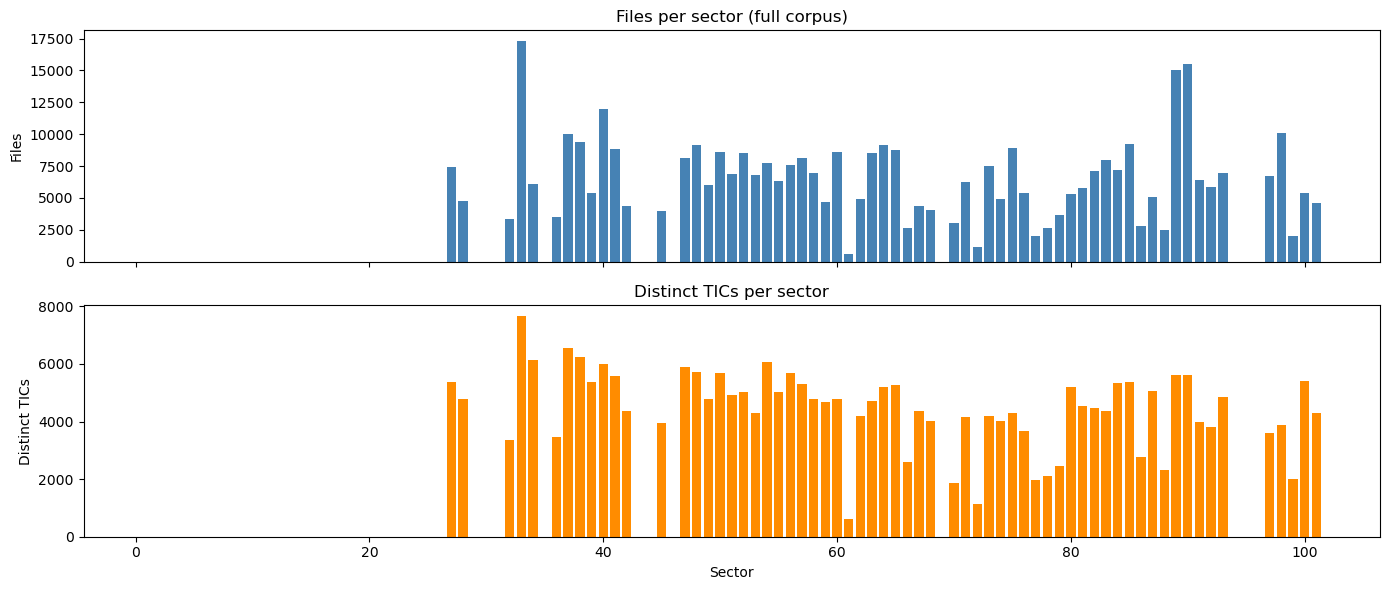

In [7]:
def plot_per_sector_coverage(df: pd.DataFrame) -> None:
    """Two-panel bar chart: files-per-sector and distinct-TICs-per-sector (full corpus)."""
    if df.empty:
        print("Empty corpus index.")
        return
    files_per_sector = df.groupby("sector").size()
    tics_per_sector  = df.groupby("sector")["tic_id"].nunique()
    sectors = list(range(1, int(df["sector"].max()) + 1))

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    axes[0].bar(sectors, [files_per_sector.get(s, 0) for s in sectors], color="steelblue")
    axes[0].set_ylabel("Files"); axes[0].set_title("Files per sector (full corpus)")
    axes[1].bar(sectors, [tics_per_sector.get(s, 0) for s in sectors], color="darkorange")
    axes[1].set_ylabel("Distinct TICs"); axes[1].set_xlabel("Sector")
    axes[1].set_title("Distinct TICs per sector")
    plt.tight_layout(); plt.show()

    empty = [s for s in sectors if files_per_sector.get(s, 0) == 0]
    if empty:
        print(f"WARNING: sectors with 0 files: {empty}")


plot_per_sector_coverage(corpus_df)

## Section 2d — TIC coverage vs `spoc_sector_map.csv`

Reads the 195k-row target list (the input the bulk pipeline iterated over) and reports what fraction of target `(TIC, sector)` pairs — and unique TICs — produced ≥1 `.npz` file. Also flags any corpus pairs/TICs that are **not** in the target list (would indicate the build script processed off-target rows).

In [8]:
def coverage_vs_targets(corpus: pd.DataFrame, target_csv: Path) -> None:
    """Report fraction of target (TIC, sector) pairs and TICs with ≥1 .npz file."""
    targets = pd.read_csv(target_csv, usecols=["tic_id", "sector"])
    target_pairs = set(map(tuple, targets[["tic_id", "sector"]].to_numpy().tolist()))
    target_tics  = set(targets["tic_id"].unique().tolist())

    done_pairs = set(map(tuple, corpus[["tic_id", "sector"]].to_numpy().tolist()))
    done_tics  = set(corpus["tic_id"].unique().tolist())

    pair_hit = len(target_pairs & done_pairs)
    tic_hit  = len(target_tics & done_tics)

    print(f"Target (TIC, sector) pairs:           {len(target_pairs):>10,}")
    print(f"  with ≥1 .npz file:                  {pair_hit:>10,}  "
          f"({pair_hit/len(target_pairs):.1%})")
    print()
    print(f"Target distinct TICs:                 {len(target_tics):>10,}")
    print(f"  with ≥1 .npz file (any sector):     {tic_hit:>10,}  "
          f"({tic_hit/len(target_tics):.1%})")

    extra_pairs = done_pairs - target_pairs
    extra_tics  = done_tics  - target_tics
    if extra_pairs or extra_tics:
        print()
        print(f"WARNING: corpus contains {len(extra_pairs):,} pairs / "
              f"{len(extra_tics):,} TICs NOT in target list")


coverage_vs_targets(corpus_df, TARGET_CSV)

Target (TIC, sector) pairs:              669,269
  with ≥1 .npz file:                     284,814  (42.6%)

Target distinct TICs:                    195,883
  with ≥1 .npz file (any sector):        120,320  (61.4%)



## Section 2e — Outlier + duplicate audit

**Outliers** (sample): files with `flux_absmax > FLUX_ABSMAX_THRESH` are written to `processed/flux_outliers_sample.csv` for downstream review.

**Duplicates** (full corpus): for any `(tic_id, sector, seg_idx)` triple with more than one `run_idx`, open the corresponding NPZs and verify their `times` ranges are disjoint. Overlap would indicate a windowing bug. Inspects up to 5 such groups.

In [9]:
def dump_outliers(
    df_checks: pd.DataFrame, out_csv: Path, threshold: float = FLUX_ABSMAX_THRESH
) -> int:
    """Write sample rows with flux_absmax > threshold to out_csv. Returns count."""
    bad = df_checks[df_checks["flux_absmax"] > threshold].copy()
    bad = bad[["file", "tic_id", "sector", "n_windows", "flux_absmax"]]
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    bad.to_csv(out_csv, index=False)
    return len(bad)


def audit_duplicates(corpus: pd.DataFrame, sample_n: int = 5) -> None:
    """For (tic, sector, seg) groups with >1 run_idx, verify time ranges are disjoint."""
    grouped = corpus.groupby(["tic_id", "sector", "seg_idx"])["run_idx"].nunique()
    dup_keys = grouped[grouped > 1]
    print(f"(tic_id, sector, seg_idx) groups with >1 run_idx: {len(dup_keys)}")
    if len(dup_keys) == 0:
        return
    for tic, sec, seg in dup_keys.head(sample_n).index.tolist():
        rows = corpus[
            (corpus.tic_id == tic) & (corpus.sector == sec) & (corpus.seg_idx == seg)
        ].sort_values("run_idx")
        ranges = []
        for _, r in rows.iterrows():
            t = np.load(r["path"], allow_pickle=True)["times"]
            ranges.append((int(r["run_idx"]), float(t.min()), float(t.max())))
        ranges.sort(key=lambda x: x[1])
        ok = all(ranges[i][2] < ranges[i + 1][1] for i in range(len(ranges) - 1))
        status = "OK" if ok else "OVERLAP"
        pretty = [(r, round(lo, 3), round(hi, 3)) for r, lo, hi in ranges]
        print(f"  TIC {tic} s{sec:02d} seg{seg:02d}: {status}  {pretty}")


n_out = dump_outliers(df_checks, OUTLIER_CSV)
print(f"Outlier sample rows (flux_absmax > {FLUX_ABSMAX_THRESH}): {n_out}  "
      f"→  saved to {OUTLIER_CSV}")
print()
audit_duplicates(corpus_df)

Outlier sample rows (flux_absmax > 20): 19  →  saved to ..\..\processed\flux_outliers_sample.csv

(tic_id, sector, seg_idx) groups with >1 run_idx: 0


### Outlier viewer — inspect flagged files one-by-one

Change `FILE_IDX` to step through the 18 outlier files (sorted worst-first by `flux_absmax`).
Change `WINDOW_IDX` to zoom into a specific window within that file.

**Top panel:** full reconstructed segment (all windows stitched), with per-window absmax annotated.
**Bottom panel:** zoomed view of the selected window on real TBJD axis.

Outlier files: 19  (threshold=20)
Showing FILE_IDX=14  WINDOW_IDX=2

[14/18]  TIC 114233889  sector=91  seg=34  n_windows=4  file_flux_absmax=26.055
Per-window absmax: ['26.05', '20.74', '26.05', '25.47']
Viewing window 2  (absmax=26.05)



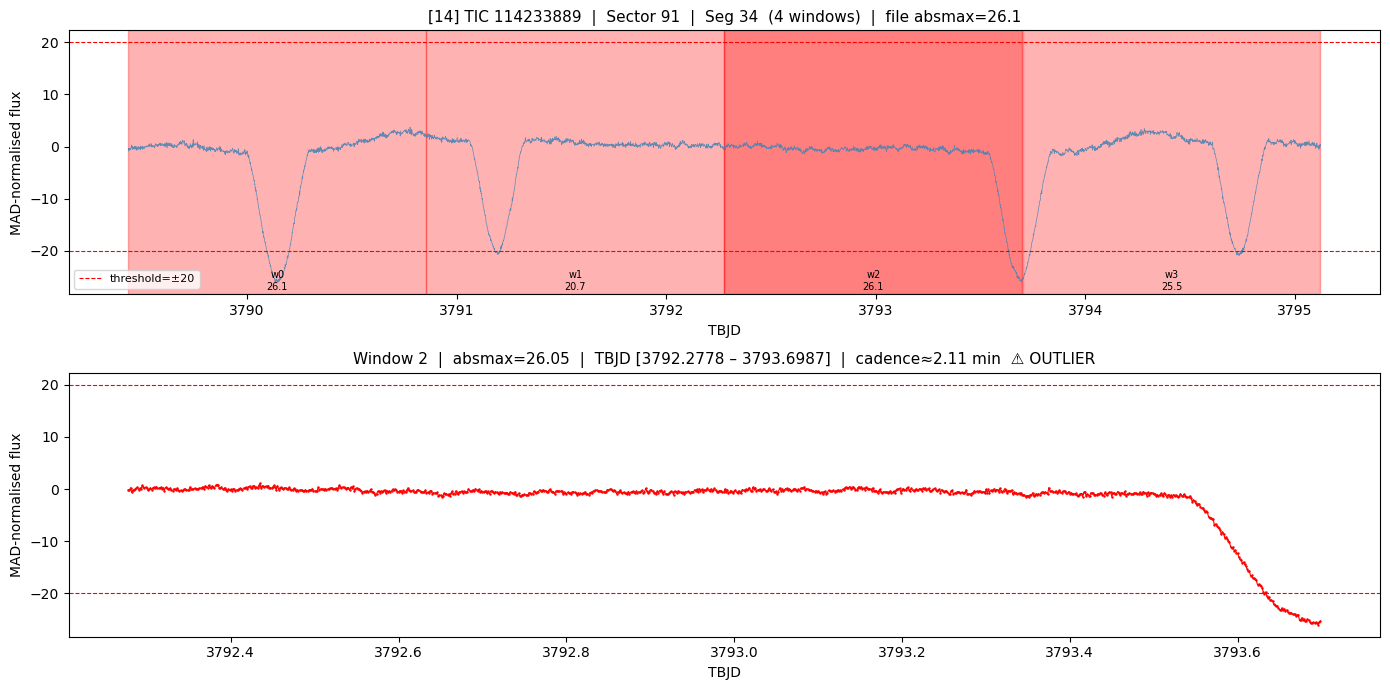

In [10]:
# ── Controls ──────────────────────────────────────────────────────────────────
FILE_IDX   = 14    # 0 .. len(outlier_files)-1; sorted worst-first by flux_absmax
WINDOW_IDX = 2    # 0 .. n_windows-1 within the selected file

# ── Build sorted outlier list ─────────────────────────────────────────────────
outlier_df = df_checks[df_checks["flux_absmax"] > FLUX_ABSMAX_THRESH].copy()
outlier_df = outlier_df.sort_values("flux_absmax", ascending=False).reset_index(drop=True)
print(f"Outlier files: {len(outlier_df)}  (threshold={FLUX_ABSMAX_THRESH})")
print(f"Showing FILE_IDX={FILE_IDX}  WINDOW_IDX={WINDOW_IDX}\n")

if FILE_IDX >= len(outlier_df):
    raise IndexError(f"FILE_IDX={FILE_IDX} but only {len(outlier_df)} outlier files")

row = outlier_df.iloc[FILE_IDX]
npz_path = SEQ_DIR / row["file"]
d = np.load(npz_path, allow_pickle=True)
windows = d["windows"].squeeze(-1)  # (N, 1024)
times   = d["times"]                # (N, 1024)
tic_id  = int(d["tic_id"])
sector  = int(d["sector"])
seg_idx = int(d["seg_idx"])
n_win   = windows.shape[0]
w_idx   = min(WINDOW_IDX, n_win - 1)

per_window_absmax = [float(np.max(np.abs(windows[i]))) for i in range(n_win)]

print(f"[{FILE_IDX}/{len(outlier_df)-1}]  TIC {tic_id}  sector={sector}  seg={seg_idx}  "
      f"n_windows={n_win}  file_flux_absmax={row['flux_absmax']:.3f}")
print(f"Per-window absmax: {['%.2f' % v for v in per_window_absmax]}")
print(f"Viewing window {w_idx}  (absmax={per_window_absmax[w_idx]:.2f})\n")

# ── Stitch windows into segment ──────────────────────────────────────────────
def _stitch(w: np.ndarray, t: np.ndarray, stride: int):
    n, tlen = w.shape
    total = (n - 1) * stride + tlen
    flux = np.full(total, np.nan)
    time = np.full(total, np.nan)
    for i in range(n):
        s = i * stride
        flux[s:s + tlen] = w[i]
        time[s:s + tlen] = t[i]
    return flux, time

flux_seg, time_seg = _stitch(windows, times, STRIDE)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Top — full segment with per-window shading
ax = axes[0]
ax.plot(time_seg, flux_seg, lw=0.5, color="steelblue", alpha=0.85)
for i in range(n_win):
    t0, t1 = float(times[i, 0]), float(times[i, -1])
    c = "red" if per_window_absmax[i] > FLUX_ABSMAX_THRESH else "lightblue"
    alpha = 0.30 if i != w_idx else 0.50
    ax.axvspan(t0, t1, color=c, alpha=alpha)
ax.axhline(FLUX_ABSMAX_THRESH, color="red", ls="--", lw=0.8, label=f"threshold=±{FLUX_ABSMAX_THRESH}")
ax.axhline(-FLUX_ABSMAX_THRESH, color="red", ls="--", lw=0.8)
ax.set_title(f"[{FILE_IDX}] TIC {tic_id}  |  Sector {sector}  |  Seg {seg_idx}  "
             f"({n_win} windows)  |  file absmax={row['flux_absmax']:.1f}", fontsize=11)
ax.set_ylabel("MAD-normalised flux")
ax.set_xlabel("TBJD")
ax.legend(fontsize=8)
# annotate per-window absmax after y-limits are set
ylo = ax.get_ylim()[0]
for i in range(n_win):
    t0, t1 = float(times[i, 0]), float(times[i, -1])
    ax.text((t0 + t1) / 2, ylo + 0.5, f"w{i}\n{per_window_absmax[i]:.1f}",
            fontsize=7, ha="center", va="bottom")

# Bottom — zoomed selected window
ax = axes[1]
win_flux = windows[w_idx]
win_time = times[w_idx]
is_outlier_win = per_window_absmax[w_idx] > FLUX_ABSMAX_THRESH
color = "red" if is_outlier_win else "darkorange"
ax.plot(win_time, win_flux, lw=0.8, color=color, marker=".", ms=1.5)
ax.axhline(FLUX_ABSMAX_THRESH, color="red", ls="--", lw=0.8)
ax.axhline(-FLUX_ABSMAX_THRESH, color="red", ls="--", lw=0.8)
cadence_min = float(np.median(np.diff(win_time))) * 1440
ax.set_title(f"Window {w_idx}  |  absmax={per_window_absmax[w_idx]:.2f}  "
             f"|  TBJD [{win_time[0]:.4f} – {win_time[-1]:.4f}]  "
             f"|  cadence≈{cadence_min:.2f} min"
             f"{'  ⚠ OUTLIER' if is_outlier_win else ''}", fontsize=11)
ax.set_ylabel("MAD-normalised flux")
ax.set_xlabel("TBJD")

plt.tight_layout()
plt.show()

## Section 2f — v1 label coverage

Joins `corpus_df["tic_id"]` against `labels/variability_labels_star.csv`. Reports:

- 2×2 rotation × transit counts among labeled corpus TICs
- Positive label rate per class
- Rotation-period regression set size (corpus TICs with `rotation==1` AND finite `rotation_period`)

Flare label excluded (ADR-0001). v1b spectroscopic (Teff/logg/[Fe/H]) intentionally out of scope.

In [11]:
def label_coverage_v1(corpus: pd.DataFrame, labels_csv: Path) -> None:
    """Print v1 label coverage: rotation × transit + rotation-period regression set size.

    Flare excluded (ADR-0001). v1b spectroscopic intentionally out of scope.
    """
    labels = pd.read_csv(labels_csv)
    needed = {"tic_id", "rotation", "transit", "rotation_period"}
    missing = needed - set(labels.columns)
    if missing:
        raise KeyError(f"labels CSV missing columns: {missing}")

    corpus_tics = pd.Series(corpus["tic_id"].unique(), name="tic_id")
    joined = labels.merge(corpus_tics.to_frame(), on="tic_id", how="inner")

    print(f"Corpus TICs:                            {len(corpus_tics):>10,}")
    print(f"  with a v1 label row:                  {len(joined):>10,}  "
          f"({len(joined)/len(corpus_tics):.1%})")
    print()

    # 2×2 rotation × transit (binary)
    rot = joined["rotation"].fillna(0).astype(int)
    trn = joined["transit"].fillna(0).astype(int)
    table = pd.crosstab(rot, trn, rownames=["rotation"], colnames=["transit"], margins=True)
    print("Rotation × Transit (counts among labeled corpus TICs):")
    print(table)
    print()
    print(f"Positive rotation rate: {(rot == 1).mean():.3%}")
    print(f"Positive transit  rate: {(trn == 1).mean():.3%}")
    print()

    # Rotation-period regression (v1-supplementary)
    rot_pos = joined[joined["rotation"] == 1]
    has_period = rot_pos["rotation_period"].notna() & np.isfinite(rot_pos["rotation_period"])
    print("Rotation-period regression (v1-supplementary):")
    print(f"  rotation==1 corpus TICs:              {len(rot_pos):>10,}")
    print(f"  with finite rotation_period:          {int(has_period.sum()):>10,}  "
          f"({has_period.mean():.1%})" if len(rot_pos) else "  (no rotation==1 TICs)")


label_coverage_v1(corpus_df, LABELS_CSV)

Corpus TICs:                               120,320
  with a v1 label row:                     120,320  (100.0%)

Rotation × Transit (counts among labeled corpus TICs):
transit        0    1     All
rotation                     
0         104457  670  105127
1          15045  148   15193
All       119502  818  120320

Positive rotation rate: 12.627%
Positive transit  rate: 0.680%

Rotation-period regression (v1-supplementary):
  rotation==1 corpus TICs:                  15,193
  with finite rotation_period:              15,193  (100.0%)


## Section 3 — Distribution plots (sample)

Four panels from `df_checks` (stratified sample, not full corpus):

- **n_windows per file** — distribution of windows per file
- **Cadence spacing** — median within-window cadence; should peak at ~0.00139 days (2 min)
- **TBJD range by sector** — `tbjd_min` scatter coloured by sector; should be sector-monotone
- **Flux abs-max** — distribution of `flux_absmax`; values > `FLUX_ABSMAX_THRESH` are unusual

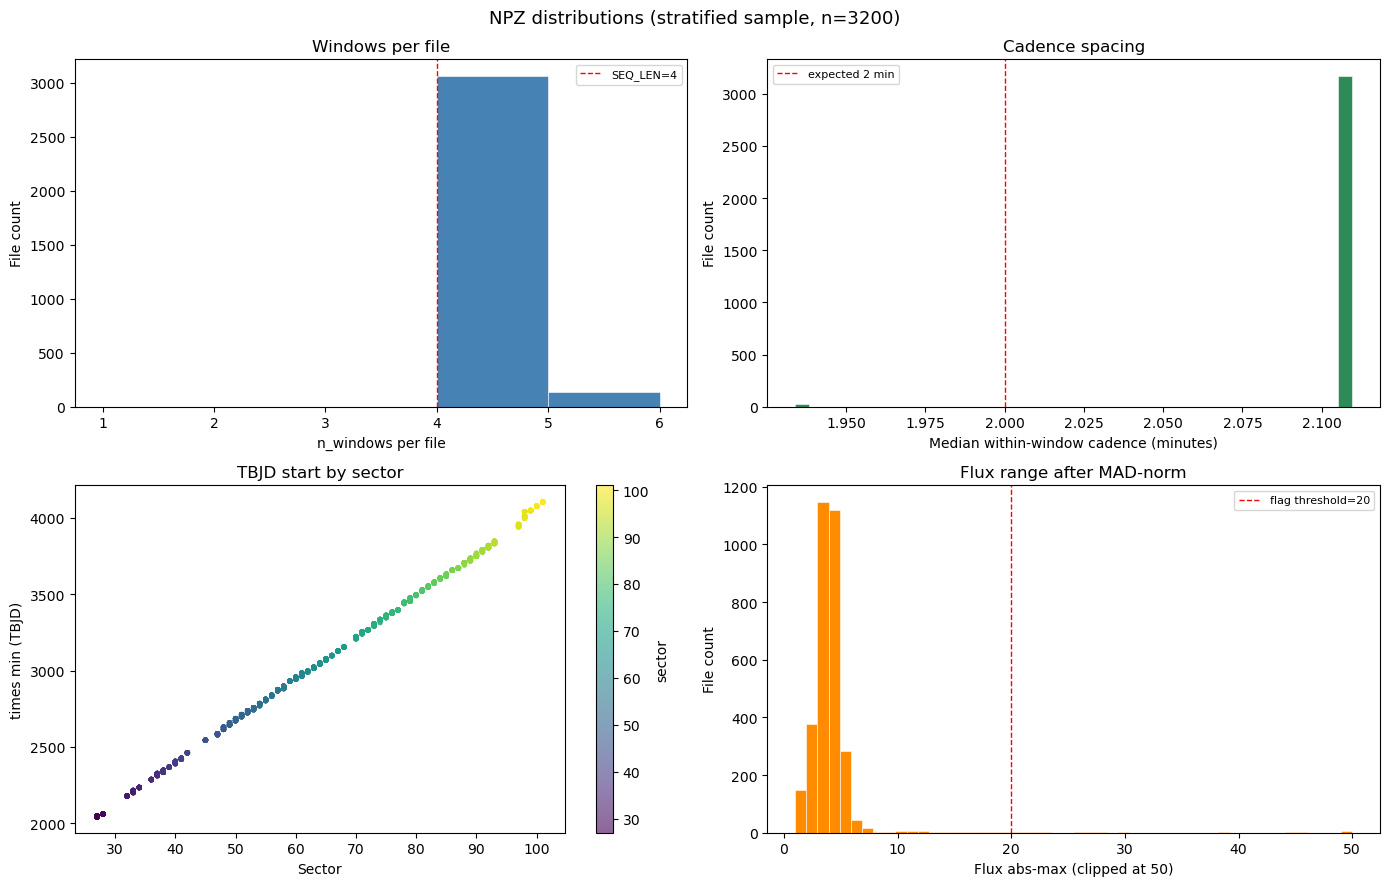


Summary statistics (sample):


,n_windows,cadence_median_days,tbjd_min,tbjd_max,flux_absmax,windows_nan,cross_window_bad_gaps
count,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0,3200.0
mean,4.0419,0.0015,3094.2418,3099.9889,4.2923,0.0,0.0
std,0.2003,0.0000,559.4889,559.4897,6.5555,0.0,0.0
min,4.0000,0.0013,2042.3240,2048.0110,0.9820,0.0,0.0
25%,4.0000,0.0015,2668.7823,2674.4700,3.3265,0.0,0.0
50%,4.0000,0.0015,3086.9325,3092.6205,3.8800,0.0,0.0
75%,4.0000,0.0015,3557.3112,3562.9985,4.4290,0.0,0.0
max,5.0000,0.0015,4107.2720,4112.9600,239.1220,0.0,0.0


In [12]:
def plot_distributions(df: pd.DataFrame) -> None:
    """Four-panel distribution figure for df_checks (sample)."""
    if df.empty:
        print("No rows to plot.")
        return
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle(f"NPZ distributions (stratified sample, n={len(df)})", fontsize=13)

    # 1. n_windows per file
    ax = axes[0, 0]
    ax.hist(df["n_windows"], bins=range(1, int(df["n_windows"].max()) + 2),
            color="steelblue", edgecolor="white", linewidth=0.4)
    ax.axvline(SEQ_LEN, color="red", linestyle="--", linewidth=1, label=f"SEQ_LEN={SEQ_LEN}")
    ax.set_xlabel("n_windows per file"); ax.set_ylabel("File count")
    ax.set_title("Windows per file"); ax.legend(fontsize=8)

    # 2. Cadence spacing
    ax = axes[0, 1]
    cad = df["cadence_median_days"].dropna() * 1440
    ax.hist(cad, bins=40, color="seagreen", edgecolor="white", linewidth=0.4)
    ax.axvline(2.0, color="red", linestyle="--", linewidth=1, label="expected 2 min")
    ax.set_xlabel("Median within-window cadence (minutes)"); ax.set_ylabel("File count")
    ax.set_title("Cadence spacing"); ax.legend(fontsize=8)

    # 3. TBJD range by sector
    ax = axes[1, 0]
    sc = ax.scatter(df["sector"], df["tbjd_min"], c=df["sector"],
                    cmap="viridis", s=8, alpha=0.6)
    plt.colorbar(sc, ax=ax, label="sector")
    ax.set_xlabel("Sector"); ax.set_ylabel("times min (TBJD)")
    ax.set_title("TBJD start by sector")

    # 4. Flux abs-max
    ax = axes[1, 1]
    ax.hist(df["flux_absmax"].clip(upper=50), bins=50, color="darkorange",
            edgecolor="white", linewidth=0.4)
    ax.axvline(FLUX_ABSMAX_THRESH, color="red", linestyle="--", linewidth=1,
               label=f"flag threshold={FLUX_ABSMAX_THRESH}")
    ax.set_xlabel("Flux abs-max (clipped at 50)"); ax.set_ylabel("File count")
    ax.set_title("Flux range after MAD-norm"); ax.legend(fontsize=8)

    plt.tight_layout(); plt.show()

    cols = ["n_windows", "cadence_median_days", "tbjd_min", "tbjd_max",
            "flux_absmax", "windows_nan", "cross_window_bad_gaps"]
    print("\nSummary statistics (sample):")
    display(df[cols].describe().round(4))


plot_distributions(df_checks)

## Section 4 — Detailed view (flux + time axis)

Randomly samples `N_SAMPLE` files and plots:
- **Top**: reconstructed segment on the real TBJD time axis, with the selected window highlighted  
- **Bottom**: zoomed view of that window; x-axis is real TBJD, not cadence offset

TIC 239975109  sector=72  seg=1  n_windows=4  showing window 0


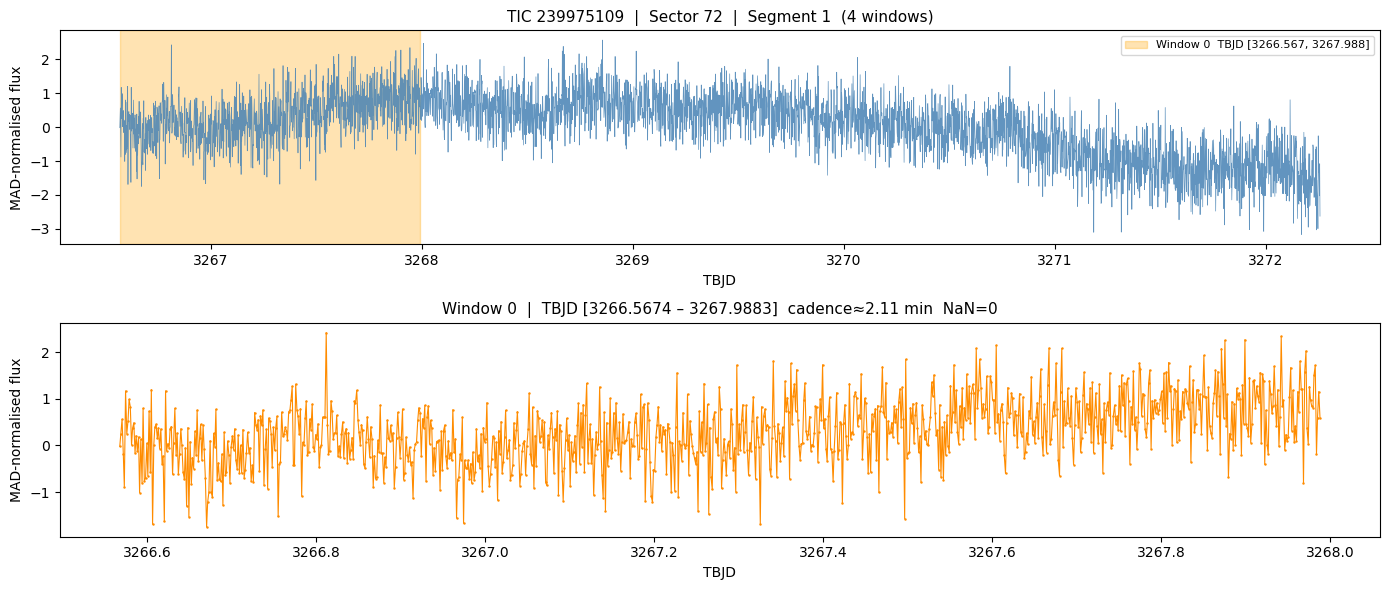

TIC 215920998  sector=80  seg=19  n_windows=4  showing window 0


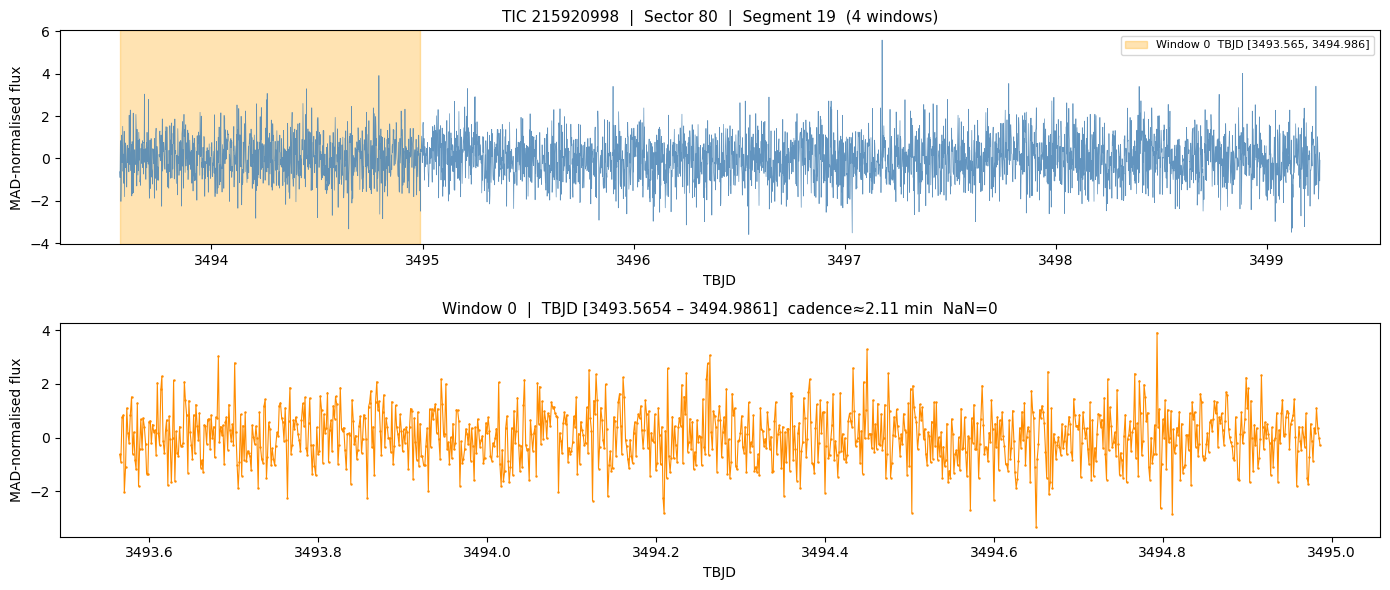

TIC 30181300  sector=101  seg=0  n_windows=4  showing window 0


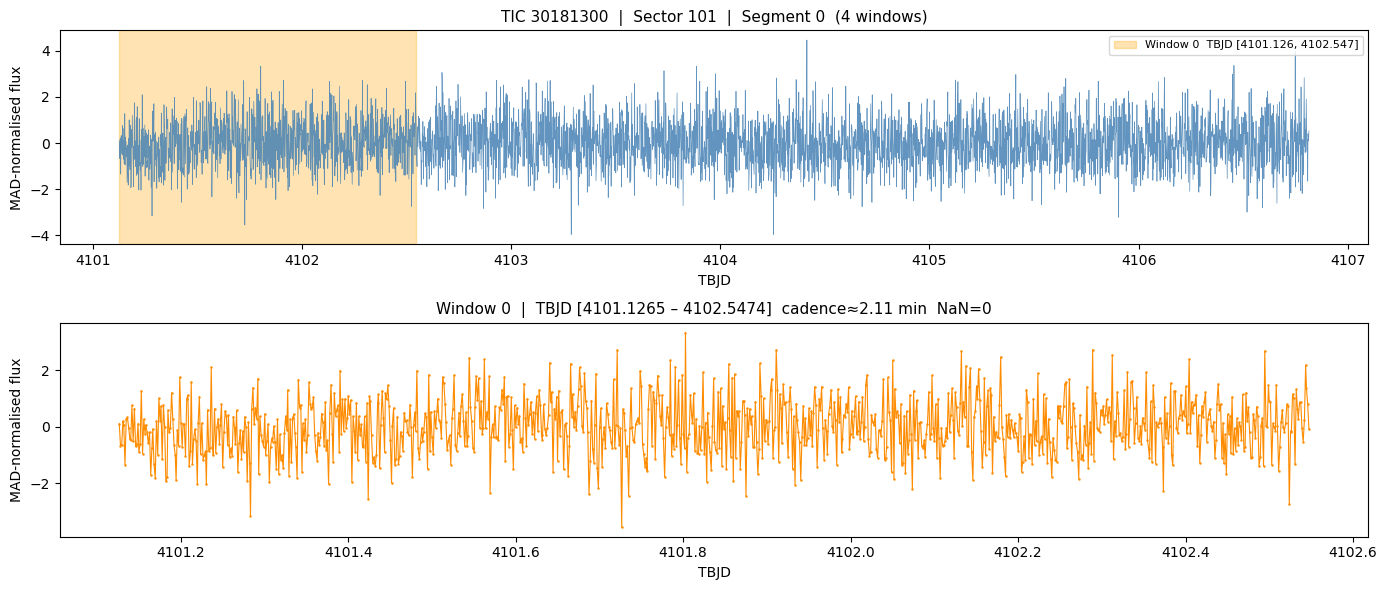

In [13]:
N_SAMPLE   = 3    # number of files to inspect visually
WINDOW_IDX = 0    # which window to highlight; clipped to [0, n_windows-1]


def reconstruct_segment_timed(
    windows: np.ndarray, times: np.ndarray, stride: int
) -> tuple[np.ndarray, np.ndarray]:
    """Stitch windows into an approximate segment using real timestamps.

    windows: (N, T)  flux array (squeezed)
    times:   (N, T)  TBJD array
    Returns (flux_1d, time_1d) of length (N-1)*stride + T.
    Later windows overwrite earlier ones in the overlap zone.
    """
    n, t = windows.shape
    total = (n - 1) * stride + t
    flux_seg = np.full(total, np.nan)
    time_seg = np.full(total, np.nan)
    for i in range(n):
        s = i * stride
        flux_seg[s : s + t] = windows[i]
        time_seg[s : s + t] = times[i]
    return flux_seg, time_seg


def plot_detail(npz_path: Path, window_idx: int = 0) -> None:
    """Plot reconstructed segment (top) and zoomed window (bottom) for one NPZ."""
    d        = np.load(npz_path, allow_pickle=True)
    windows  = d["windows"].squeeze(-1)              # (N, 1024)
    times    = d["times"]                            # (N, 1024)
    tic_id   = int(d["tic_id"])
    sector   = int(d["sector"])
    seg_idx  = int(d["seg_idx"])
    n_win    = windows.shape[0]
    window_idx = min(window_idx, n_win - 1)

    print(
        f"TIC {tic_id}  sector={sector}  seg={seg_idx}  "
        f"n_windows={n_win}  showing window {window_idx}"
    )

    flux_seg, time_seg = reconstruct_segment_timed(windows, times, STRIDE)
    win_time = times[window_idx]

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

    # Top — full reconstructed segment
    axes[0].plot(time_seg, flux_seg, lw=0.5, color="steelblue", alpha=0.85)
    axes[0].axvspan(
        float(win_time[0]), float(win_time[-1]),
        color="orange", alpha=0.30,
        label=f"Window {window_idx}  TBJD [{win_time[0]:.3f}, {win_time[-1]:.3f}]",
    )
    axes[0].set_title(
        f"TIC {tic_id}  |  Sector {sector}  |  Segment {seg_idx}  ({n_win} windows)",
        fontsize=11,
    )
    axes[0].set_ylabel("MAD-normalised flux"); axes[0].set_xlabel("TBJD")
    axes[0].legend(fontsize=8, loc="upper right")

    # Bottom — zoomed window
    win_flux = windows[window_idx]
    nan_ct   = int(np.isnan(win_flux).sum())
    axes[1].plot(win_time, win_flux, lw=0.8, color="darkorange", marker=".", ms=1.5)
    cadence_min = float(np.median(np.diff(win_time))) * 1440
    axes[1].set_title(
        f"Window {window_idx}  |  TBJD [{win_time[0]:.4f} – {win_time[-1]:.4f}]  "
        f"cadence≈{cadence_min:.2f} min  NaN={nan_ct}",
        fontsize=11,
    )
    axes[1].set_ylabel("MAD-normalised flux"); axes[1].set_xlabel("TBJD")
    plt.tight_layout(); plt.show()


rng           = random.Random(SEED)
detail_sample = rng.sample(sample_paths, min(N_SAMPLE, len(sample_paths)))
for path in detail_sample:
    plot_detail(path, window_idx=WINDOW_IDX)

## Section 5a — Full-corpus flux-outlier scan + label cross-match (read-only)

Scans **every** `.npz` in the corpus, loads only `windows`, computes `flux_absmax`. Files exceeding `FLUX_ABSMAX_THRESH` are written to `processed/flux_outliers_cleanup_manifest.csv`.

Before any deletion, prints:
- Total outlier files and distinct TICs
- Per-(TIC, sector) pair breakdown: all-outlier vs partial-outlier (drives the progress-CSV patch in 5b)
- **Label cross-match** against the four v1 labels in `variability_labels_star.csv` (`rotation`/TARS, `transit`/TOI, `eb`/Villanova, `pulsating`/Gao), reporting for each:
  - **+ touched** — positive TICs with ≥1 window deleted
  - **+ lost from eval** — positive TICs whose *every* window (all sectors) is deleted, so they leave the probe eval set

Outlier windows are deleted regardless of label (a flux artifact poisons the latent for both pretraining and probing); the report quantifies the eval-set cost.

**No files are deleted by this cell.**

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
CLEANUP_WORKERS = 16
MANIFEST_CSV    = Path("../../processed/flux_outliers_cleanup_manifest.csv")


# ── 1. Full-corpus flux_absmax scan ──────────────────────────────────────────

def _file_absmax(path_str: str) -> tuple[str, float]:
    """Load only windows from one .npz, return (filename, flux_absmax).

    Uses a context manager so the NpzFile handle is closed before returning.
    On Windows a lingering open handle would later block unlink() in 5b.
    """
    p = Path(path_str)
    try:
        with np.load(p, allow_pickle=True) as d:
            return (p.name, float(np.max(np.abs(d["windows"]))))  # (N, 1024, 1)
    except Exception:
        return (p.name, np.nan)


print(f"Scanning {len(corpus_df):,} files with {CLEANUP_WORKERS} workers ...")
import time as _time
_t0 = _time.perf_counter()

with ThreadPoolExecutor(max_workers=CLEANUP_WORKERS) as pool:
    results = list(pool.map(_file_absmax, corpus_df["path"].tolist()))

_elapsed = _time.perf_counter() - _t0
print(f"Done in {_elapsed:.0f}s")

scan_df = pd.DataFrame(results, columns=["file", "flux_absmax"])
scan_df = scan_df.merge(
    corpus_df[["path", "tic_id", "sector", "seg_idx", "run_idx"]].assign(
        file=corpus_df["path"].map(lambda p: Path(p).name)
    ),
    on="file",
    how="left",
)

outliers = scan_df[scan_df["flux_absmax"] > FLUX_ABSMAX_THRESH].copy()
outliers = outliers.sort_values("flux_absmax", ascending=False).reset_index(drop=True)

# ── 2. Write manifest ────────────────────────────────────────────────────────
manifest_cols = ["file", "tic_id", "sector", "seg_idx", "run_idx", "flux_absmax"]
outliers[manifest_cols].to_csv(MANIFEST_CSV, index=False)

print(f"\nOutlier files:      {len(outliers):>10,} / {len(scan_df):,}  "
      f"({len(outliers)/len(scan_df):.2%})")
print(f"Distinct TICs:      {outliers['tic_id'].nunique():>10,}")
print(f"Manifest saved to:  {MANIFEST_CSV}")

# ── 3. Per-(TIC, sector) pair breakdown ──────────────────────────────────────
total_per_pair = corpus_df.groupby(["tic_id", "sector"]).size().rename("total_files")
outlier_per_pair = outliers.groupby(["tic_id", "sector"]).size().rename("outlier_files")
pair_df = pd.concat([total_per_pair, outlier_per_pair], axis=1).dropna(subset=["outlier_files"])
pair_df["outlier_files"] = pair_df["outlier_files"].astype(int)
pair_df["all_outlier"] = pair_df["outlier_files"] == pair_df["total_files"]

n_all = int(pair_df["all_outlier"].sum())
n_partial = len(pair_df) - n_all
print(f"\n(TIC, sector) pairs with outliers: {len(pair_df)}")
print(f"  ALL files are outliers (progress row will be deleted):  {n_all}")
print(f"  SOME files are outliers (progress row kept):            {n_partial}")

# ── 4. Label cross-match (all four labels from variability_labels_star.csv) ──
# EB positives = Villanova (ADR-0007); pulsating = Gao+2025; rotation = TARS;
# transit = TOI. All live as 0/1 columns in the star CSV, so no external files.
labels = pd.read_csv(LABELS_CSV)
LABEL_COLS = {
    "rotation":  "TARS (rotation)",
    "transit":   "TOI (transit)",
    "eb":        "Villanova EB",
    "pulsating": "Gao pulsating",
}

outlier_tics = set(outliers["tic_id"].unique())

# TICs that lose ALL their windows = every corpus .npz for that TIC is an outlier.
# Labels are per-TIC and the probe keeps a star while ANY window survives in ANY
# sector, so only these TICs actually drop out of the eval set.
files_per_tic    = corpus_df.groupby("tic_id").size()
outliers_per_tic = outliers.groupby("tic_id").size()
lost_all_tics = set(
    outliers_per_tic[outliers_per_tic == files_per_tic.reindex(outliers_per_tic.index)].index
)

print(f"Outlier TICs (touched at all):            {len(outlier_tics):>8,}")
print(f"TICs losing ALL windows (drop from eval): {len(lost_all_tics):>8,}")

print(f"{'Label':<20} {'+ touched':>12} {'+ lost from eval':>18}")
print("-" * 52)
for col, name in LABEL_COLS.items():
    pos_tics = set(labels.loc[labels[col] == 1, "tic_id"])
    touched  = len(outlier_tics  & pos_tics)   # (a) positive, ≥1 window deleted
    lost     = len(lost_all_tics & pos_tics)   # (b) positive, ALL windows deleted
    print(f"{name:<20} {touched:>12,} {lost:>18,}")


## Section 5b — Execute cleanup (DESTRUCTIVE)

Reads the manifest written by Section 5a, deletes the listed `.npz` files, and patches `build_sequences_bulk_progress.csv`:

- **(TIC, sector) pairs where ALL files are outliers:** progress row is **deleted** so `--resume` will reprocess them (the `--max-flux-absmax` guard in the build script prevents re-emitting outlier segments).
- **Partial-outlier pairs:** progress row is **kept** — clean siblings remain, and `--max-flux-absmax` prevents the deleted segments from being re-emitted.

**Run Section 5a first.** Review its output before executing this cell.

In [18]:
import gc

# ── 0. Release stale NpzFile handles ──────────────────────────────────────────
# Diagnostic cells (Section 2e outlier viewer, Section 4 detail view) assign a
# module-level `d = np.load(...)` that keeps the file handle OPEN. On Windows an
# open handle makes unlink() raise PermissionError [WinError 32]. Drop those
# names and force a GC pass before deleting.
for _name in ("d", "windows", "times", "flux_seg", "time_seg",
              "win_flux", "win_time", "npz_path"):
    globals().pop(_name, None)
gc.collect()

# ── 1. Load manifest ──────────────────────────────────────────────────────────
manifest = pd.read_csv(MANIFEST_CSV)
print(f"Manifest: {len(manifest):,} outlier files to delete")

if manifest.empty:
    print("Nothing to clean up.")
else:
    # ── 2. Identify all-outlier (TIC, sector) pairs ──────────────────────────
    total_per_pair = corpus_df.groupby(["tic_id", "sector"]).size().rename("total_files")
    outlier_per_pair = manifest.groupby(["tic_id", "sector"]).size().rename("outlier_files")
    pair_df = pd.concat([total_per_pair, outlier_per_pair], axis=1).dropna(subset=["outlier_files"])
    pair_df["outlier_files"] = pair_df["outlier_files"].astype(int)
    all_outlier_pairs: set[tuple[int, int]] = set(
        pair_df[pair_df["outlier_files"] == pair_df["total_files"]].index.tolist()
    )
    partial_pairs: set[tuple[int, int]] = set(pair_df.index.tolist()) - all_outlier_pairs

    # ── 3. Delete .npz files (retry once on transient lock) ──────────────────
    deleted = 0
    missing = 0
    locked: list[str] = []
    for fname in manifest["file"]:
        p = SEQ_DIR / fname
        if not p.exists():
            missing += 1
            continue
        try:
            p.unlink()
            deleted += 1
        except PermissionError:
            gc.collect()                 # drop any lingering handle, then retry
            try:
                p.unlink()
                deleted += 1
            except PermissionError:
                locked.append(fname)

    print(f"Files deleted:   {deleted:>10,}")
    if missing:
        print(f"Files not found: {missing:>10,}  (already removed?)")
    if locked:
        print(f"Files LOCKED:    {len(locked):>10,}  (still held by a process)")
        print("  Restart the kernel and re-run Section 5b to clear these.")
        for f in locked[:10]:
            print(f"    {f}")

    # ── 4. Patch progress CSV (only for pairs whose files all got deleted) ───
    # Skip pairs that still have a locked survivor so the progress row stays
    # consistent with what is actually on disk.
    locked_pairs = set(
        manifest.loc[manifest["file"].isin(locked), ["tic_id", "sector"]]
        .itertuples(index=False, name=None)
    )
    deletable_all_outlier = all_outlier_pairs - locked_pairs

    progress = pd.read_csv(PROGRESS_CSV)
    n_before = len(progress)
    if deletable_all_outlier:
        mask = progress.apply(
            lambda r: (int(r["tic_id"]), int(r["sector"])) in deletable_all_outlier, axis=1
        )
        progress = progress[~mask]
    n_removed = n_before - len(progress)
    progress.to_csv(PROGRESS_CSV, index=False)

    print(f"Progress CSV rows before: {n_before:>10,}")
    print(f"Progress rows deleted:   {n_removed:>10,}  (all-outlier pairs, fully cleaned)")
    print(f"Progress CSV rows after: {len(progress):>10,}")
    print(f"Partial-cleanup pairs (progress row kept): {len(partial_pairs)}")
    print(f"Done. Re-run Section 0 to verify updated corpus counts.")


Manifest: 677 outlier files to delete
Files deleted:          677
Progress CSV rows before:    669,142
Progress rows deleted:          314  (all-outlier pairs, fully cleaned)
Progress CSV rows after:    668,828
Partial-cleanup pairs (progress row kept): 282
Done. Re-run Section 0 to verify updated corpus counts.
